# Frontier Models Analysis: GPT-4.1 & GPT-5.1

Compares frontier models (GPT-4.1, GPT-5.1) against open-source LLMs and human benchmarks in the Ultimatum Game with Dark Factor manipulations.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Load Data

In [2]:
# Load frontier models (GPT-4.1, GPT-5.1)
df_gpt = pd.read_csv('data/frontier_models_results.csv')
print(f"✓ Frontier models: {len(df_gpt):,} decisions")
print(f"  Models: {', '.join(df_gpt['model'].unique())}")

# Load open-source LLMs
df_oss = pd.read_csv('data/aidata.csv')
print(f"✓ Open-source: {len(df_oss):,} decisions")

# Load human benchmark
df_human = pd.read_csv('data/hudata.csv')
print(f"✓ Human: {len(df_human):,} decisions")

✓ Frontier models: 800 decisions
  Models: gpt-5.1, gpt-4.1
✓ Open-source: 339,956 decisions
✓ Human: 4,166 decisions


## Prepare Data

In [3]:
# Parse GPT decisions
df_gpt['decision_parsed'] = df_gpt['decision'].str.strip()

# Proposer: A=prosocial (50-50), B=selfish (90-10)
df_gpt_prop = df_gpt[df_gpt['role'] == 'proposer'].copy()
df_gpt_prop['prosocial'] = df_gpt_prop['decision_parsed'].map({'A': 1, 'B': 0})

# Responder: Accept=prosocial
df_gpt_resp = df_gpt[df_gpt['role'] == 'responder'].copy()
df_gpt_resp['prosocial'] = df_gpt_resp['decision_parsed'].apply(
    lambda x: 1 if 'Accept' in str(x) else 0
)

# Open-source LLMs
df_oss_prop = df_oss[df_oss['role'] == 'proposer'].copy()
df_oss_resp = df_oss[df_oss['role'] == 'responder'].copy()

# Human data (fix European decimal format)
df_human['d_numeric'] = df_human['d'].astype(str).str.replace(',', '.').astype(float)

def bin_d_factor(d):
    """Convert continuous D-factor to categorical levels"""
    if d < 1.5: return 'D1'
    elif d < 2.5: return 'D2'
    elif d < 3.5: return 'D3'
    elif d < 4.5: return 'D4'
    else: return 'D5'

df_human['d_level'] = df_human['d_numeric'].apply(bin_d_factor)
df_human_prop = df_human[df_human['role'] == 'proposer'].copy()
df_human_resp = df_human[df_human['role'] == 'responder'].copy()

print("✓ Data prepared")

✓ Data prepared


## Calculate Aggregates by D-Level

In [4]:
d_order = ['D1', 'D2', 'D3', 'D4', 'D5']
d_map = {'D1': 1, 'D2': 2, 'D3': 3, 'D4': 4, 'D5': 5}

# === PROPOSER ===
human_prop = df_human_prop.groupby('d_level')['prosocial'].mean().reindex(d_order)
oss_prop = df_oss_prop.groupby('d_cat')['prosocial'].mean().reindex(d_order)

gpt_prop = {}
for model in df_gpt_prop['model'].unique():
    gpt_prop[model] = df_gpt_prop[df_gpt_prop['model'] == model].groupby('d_level')['prosocial'].mean().reindex(d_order)

# === RESPONDER ===
human_resp = df_human_resp.groupby('d_level')['prosocial'].mean().reindex(d_order)
oss_resp = df_oss_resp.groupby('d_cat')['prosocial'].mean().reindex(d_order)

gpt_resp = {}
for model in df_gpt_resp['model'].unique():
    gpt_resp[model] = df_gpt_resp[df_gpt_resp['model'] == model].groupby('d_level')['prosocial'].mean().reindex(d_order)

print("✓ Aggregates calculated")

✓ Aggregates calculated


## Proposer & Responder Comparison

Side-by-side panels showing prosocial behavior across D-Factor levels for all groups.

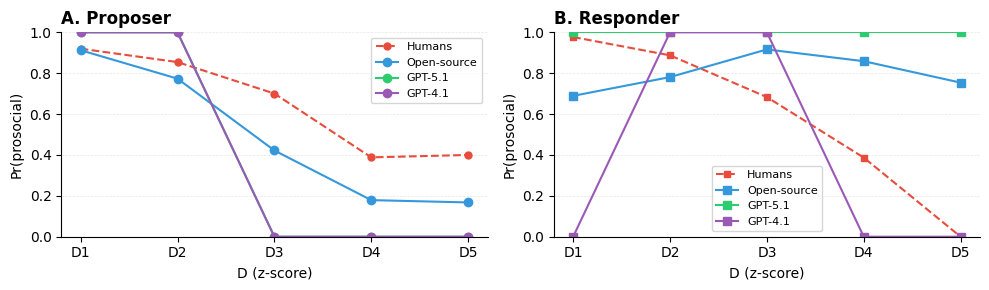

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

# Color scheme (matching paper_v2.ipynb)
color_hum = "#E74C3C"    # Red - Humans
color_ai = "#3498DB"     # Blue - Open-source AI
color_gpt5 = "#2ECC71"   # Green - GPT-5.1
color_gpt4 = "#9B59B6"   # Purple - GPT-4.1

x_vals = [1, 2, 3, 4, 5]

# ========== PANEL A: PROPOSER ==========
ax1.plot(x_vals, human_prop.values, marker='o', markersize=5, linewidth=1.5,
         color=color_hum, label='Humans', linestyle='--')

ax1.plot(x_vals, oss_prop.values, marker='o', markersize=6, linewidth=1.5,
         color=color_ai, label='Open-source', linestyle='-')

for model_name, color in [('gpt-5.1', color_gpt5), ('gpt-4.1', color_gpt4)]:
    if model_name in gpt_prop:
        ax1.plot(x_vals, gpt_prop[model_name].values, marker='o', markersize=6, linewidth=1.5,
                color=color, label=f'{model_name.upper()}', linestyle='-')

ax1.set_xlabel('D (z-score)', fontweight='medium')
ax1.set_ylabel('Pr(prosocial)', fontweight='medium')
ax1.set_title('A. Proposer', fontweight='bold', loc='left')
ax1.set_ylim(0, 1)
ax1.set_xticks(x_vals)
ax1.set_xticklabels(d_order)
ax1.set_yticks(np.arange(0, 1.1, 0.2))
ax1.yaxis.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.legend(loc='best', frameon=True, fontsize=8)

# ========== PANEL B: RESPONDER ==========
ax2.plot(x_vals, human_resp.values, marker='s', markersize=5, linewidth=1.5,
         color=color_hum, label='Humans', linestyle='--')

ax2.plot(x_vals, oss_resp.values, marker='s', markersize=6, linewidth=1.5,
         color=color_ai, label='Open-source', linestyle='-')

for model_name, color in [('gpt-5.1', color_gpt5), ('gpt-4.1', color_gpt4)]:
    if model_name in gpt_resp:
        ax2.plot(x_vals, gpt_resp[model_name].values, marker='s', markersize=6, linewidth=1.5,
                color=color, label=f'{model_name.upper()}', linestyle='-')

ax2.set_xlabel('D (z-score)', fontweight='medium')
ax2.set_ylabel('Pr(prosocial)', fontweight='medium')
ax2.set_title('B. Responder', fontweight='bold', loc='left')
ax2.set_ylim(0, 1)
ax2.set_xticks(x_vals)
ax2.set_xticklabels(d_order)
ax2.set_yticks(np.arange(0, 1.1, 0.2))
ax2.yaxis.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.legend(loc='best', frameon=True, fontsize=8)

plt.tight_layout()
#plt.savefig('gpt_compt.png', dpi=300)
plt.show()

## Statistical Analysis

In [7]:
def calc_gradient(df, d_col='d_level', y_col='prosocial'):
    """Calculate linear regression of prosocial behavior on D-factor"""
    df_temp = df.dropna(subset=[y_col, d_col]).copy()
    df_temp['d_num'] = df_temp[d_col].map(d_map)
    return stats.linregress(df_temp['d_num'], df_temp[y_col])

def calc_corr(df, d_col='d_level', y_col='prosocial'):
    """Calculate Spearman correlation between D-factor and prosocial behavior"""
    df_temp = df.dropna(subset=[y_col, d_col]).copy()
    df_temp['d_num'] = df_temp[d_col].map(d_map)
    return stats.spearmanr(df_temp['d_num'], df_temp[y_col])

# === PROPOSER: LINEAR GRADIENTS ===
print("="*80)
print("PROPOSER: D-Factor Sensitivity (Linear Regression)")
print("="*80)
print(f"{'Source':<20} {'Slope':<12} {'R²':<12} {'p-value':<12} {'N':<10}")
print("-"*80)

h_grad = calc_gradient(df_human_prop, 'd_level')
print(f"{'Humans':<20} {h_grad.slope:>11.4f} {h_grad.rvalue**2:>11.3f} {h_grad.pvalue:>11.3e} {len(df_human_prop):>9,}")

o_grad = calc_gradient(df_oss_prop, 'd_cat')
print(f"{'Open-source':<20} {o_grad.slope:>11.4f} {o_grad.rvalue**2:>11.3f} {o_grad.pvalue:>11.3e} {len(df_oss_prop):>9,}")

for model in sorted(df_gpt_prop['model'].unique()):
    model_df = df_gpt_prop[df_gpt_prop['model'] == model]
    g_grad = calc_gradient(model_df, 'd_level')
    print(f"{model.upper():<20} {g_grad.slope:>11.4f} {g_grad.rvalue**2:>11.3f} {g_grad.pvalue:>11.3e} {len(model_df):>9,}")

# === RESPONDER: SPEARMAN CORRELATIONS ===
print("\n" + "="*80)
print("RESPONDER: D-Factor Sensitivity (Spearman Correlation)")
print("="*80)
print(f"{'Source':<20} {'ρ':<12} {'p-value':<12} {'N':<10}")
print("-"*80)

h_corr = calc_corr(df_human_resp, 'd_level')
print(f"{'Humans':<20} {h_corr[0]:>11.3f} {h_corr[1]:>11.3e} {len(df_human_resp):>9,}")

o_corr = calc_corr(df_oss_resp, 'd_cat')
print(f"{'Open-source':<20} {o_corr[0]:>11.3f} {o_corr[1]:>11.3e} {len(df_oss_resp):>9,}")

for model in sorted(df_gpt_resp['model'].unique()):
    model_df = df_gpt_resp[df_gpt_resp['model'] == model]
    g_corr = calc_corr(model_df, 'd_level')
    print(f"{model.upper():<20} {g_corr[0]:>11.3f} {g_corr[1]:>11.3e} {len(model_df):>9,}")

print("\n" + "="*80)

PROPOSER: D-Factor Sensitivity (Linear Regression)
Source               Slope        R²           p-value      N         
--------------------------------------------------------------------------------
Humans                   -0.1597       0.071   4.127e-35     2,079
Open-source              -0.2084       0.347   0.000e+00   169,981
GPT-4.1                  -0.3000       0.750   1.625e-61       200
GPT-5.1                  -0.3000       0.750   1.625e-61       200

RESPONDER: D-Factor Sensitivity (Spearman Correlation)
Source               ρ            p-value      N         
--------------------------------------------------------------------------------
Humans                    -0.325   1.174e-52     2,087
Open-source                0.073  5.646e-201   169,975
GPT-4.1                   -0.289   3.391e-05       200
GPT-5.1                      nan         nan       200



## Summary Tables

In [8]:
# Proposer summary
print("PROPOSER - Prosocial Rate by D-Level")
print("="*70)
summary_prop = pd.DataFrame({
    'Humans': human_prop,
    'Open-source': oss_prop
})
for model in sorted(gpt_prop.keys()):
    summary_prop[model.upper()] = gpt_prop[model]
print(summary_prop.round(3))

# Responder summary
print("\n" + "="*70)
print("RESPONDER - Prosocial Rate by D-Level")
print("="*70)
summary_resp = pd.DataFrame({
    'Humans': human_resp,
    'Open-source': oss_resp
})
for model in sorted(gpt_resp.keys()):
    summary_resp[model.upper()] = gpt_resp[model]
print(summary_resp.round(3))

PROPOSER - Prosocial Rate by D-Level
    Humans  Open-source  GPT-4.1  GPT-5.1
D1   0.920        0.912      1.0      1.0
D2   0.854        0.773      1.0      1.0
D3   0.700        0.422      0.0      0.0
D4   0.388        0.179      0.0      0.0
D5   0.400        0.168      0.0      0.0

RESPONDER - Prosocial Rate by D-Level
    Humans  Open-source  GPT-4.1  GPT-5.1
D1   0.977        0.689      0.0      1.0
D2   0.887        0.781      1.0      1.0
D3   0.683        0.916      1.0      1.0
D4   0.387        0.859      0.0      1.0
D5   0.000        0.754      0.0      1.0
